In [ ]:
# !pip3 install torch torchvision --index-url https://download.pytorch.org/whl/rocm7.1

# !python -c "import torch; print(torch.__version__)"
# !python -c "import torch; print(torch.cuda.is_available())"
# !python -c "import torch; print(torch.cuda.device_count())"
# !python -c "import torch; print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'No GPU')"
# !python -m torch.utils.collect_env

In [2]:
TRAIN_IMAGE_PATH = "DIV2K_train_HR/"
EVAL_IMAGE_PATH = "DIV2K_valid_HR/"
MODEL_PATH = "/models/"
!ls

sample_data


In [3]:
from google.colab import drive
import sys
import os

drive.mount('/content/drive')

# Update paths for Google Colab (uses Drive)
if 'google.colab' in sys.modules:
    TRAIN_IMAGE_PATH = "drive/MyDrive/upscaler/DIV2K_train_HR/"
    EVAL_IMAGE_PATH = "drive/MyDrive/upscaler/DIV2K_valid_HR/"

# Verify paths exist
print(f"Train path exists: {os.path.exists(TRAIN_IMAGE_PATH)}")
print(f"Eval path exists:  {os.path.exists(EVAL_IMAGE_PATH)}")
!ls drive/MyDrive/upscaler/



Mounted at /content/drive
Train path exists: True
Eval path exists:  True
DIV2K_train_HR	Untitled0.ipynb
DIV2K_valid_HR	upsample_first_srcnn_512_64_scale_4_use_sharpen_True.pth
IMG_0449.jpg	upsample_first_srcnn_IMG_0449_new.png
IMG_0450.jpg	upsample_first_srcnn_IMG_7874_new.png
IMG_7874.png	upsample_first_srcnn_IMG_7874.png
models		upsample_first_srcnn.pth
png_images	upscaled_srcnn_ch128_blk32_scale4_sharpenTrue.png


In [ ]:
# =============================================================================
# CONFIGURATION - All hyperparameters and constants in one place
# =============================================================================

from dataclasses import dataclass, field, asdict
import json

@dataclass
class Config:
    """Central configuration for the super-resolution pipeline."""
    
    # ----- Model Name (REQUIRED - set this for each training run!) -----
    model_name: str = ""  # e.g., "srcnn_v1", "experiment_larger_crop", etc.
    
    # ----- Upscaling -----
    scale_factor: int = 6
    
    # ----- Dataset / Training crops -----
    hr_crop_size: int = 96  # High-resolution crop size (must be divisible by scale_factor)
    
    # ----- Data loading -----
    batch_size: int = 256
    num_workers: int = 12
    prefetch_factor: int = 12
    
    # ----- Data augmentation probabilities -----
    rotation_prob: float = 0.5
    flip_prob: float = 0.5
    
    # ----- Model architecture -----
    model_channels: int = 128
    num_residual_blocks: int = 32
    moe_kernel_size: int = 5
    moe_num_experts_head1: int = 24
    moe_num_experts_head2: int = 16
    refine_intermediate_channels: int = 16
    
    # ----- Sharpening layer defaults -----
    sharpen_radius: float = 1.2
    sharpen_percent: float = 130.0
    sharpen_threshold: float = 2.0
    use_sharpen: bool = True
    use_final_refine: bool = True
    
    # ----- MoE Sharpening -----
    sharpen_num_experts: int = 4
    use_moe_sharpen: bool = True  # If True, use MoE sharpening instead of single
    
    # Expert configurations: list of (radius, percent, threshold) tuples
    # Covers a range from subtle to aggressive sharpening
    sharpen_expert_configs: tuple = (
        (0.5, 50.0, 1.0),    # Expert 0: Very subtle - fine detail preservation
        (1.0, 100.0, 2.0),   # Expert 1: Mild - general purpose
        (1.5, 150.0, 3.0),   # Expert 2: Medium - noticeable sharpening  
        (2.0, 200.0, 4.0),   # Expert 3: Strong - aggressive sharpening
    )
    
    # ----- Training -----
    learning_rate: float = 1e-4
    weight_decay: float = 1e-4
    num_epochs: int = 120
    importance_loss_weight: float = 1e-2
    
    checkpoint_every_n_epochs: int = 10      # Save checkpoint every N epochs (0 = disabled)
    save_best_only: bool = True              # Save when validation loss improves
    keep_last_n_checkpoints: int = 3         # Keep only last N checkpoints (0 = keep all)
    
    # ----- Inference (patch-based reconstruction) -----
    inference_patch_size: int = 32
    inference_stride: int = 16
    
    # ----- Numerical stability -----
    eps: float = 1e-8
    blend_window_eps: float = 1e-3
    
    # ----- Paths -----
    drive_base_path: str = "drive/MyDrive/upscaler/"
    models_subdir: str = "models/"
    
    # ----- Derived properties -----
    @property
    def lr_crop_size(self) -> int:
        """Low-resolution crop size derived from HR and scale."""
        return self.hr_crop_size // self.scale_factor
    
    def _generate_default_name(self) -> str:
        """Generate a default model name from config parameters."""
        from datetime import datetime
        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
        return f"srcnn_ch{self.model_channels}_blk{self.num_residual_blocks}_scale{self.scale_factor}_{timestamp}"
    
    @property
    def model_folder(self) -> str:
        """Full path to this model's directory (e.g., models/srcnn_v1/)."""
        if not self.model_name:
            # Auto-generate a name if not set
            self.model_name = self._generate_default_name()
            print(f"⚠️ No model_name set - auto-generated: {self.model_name}")
        return f"{self.drive_base_path}{self.models_subdir}{self.model_name}/"
    
    @property
    def config_path(self) -> str:
        """Path to save/load config JSON."""
        return f"{self.model_folder}config.json"
    
    @property
    def best_model_path(self) -> str:
        """Path for the best model checkpoint."""
        return f"{self.model_folder}best.pth"
    
    @property
    def final_model_path(self) -> str:
        """Path for the final model after training."""
        return f"{self.model_folder}final.pth"
    
    def checkpoint_path(self, epoch: int) -> str:
        """Generate checkpoint path for a specific epoch."""
        return f"{self.model_folder}epoch_{epoch:03d}.pth"
    
    # Legacy property for compatibility
    @property
    def model_save_dir(self) -> str:
        """Alias for model_folder."""
        return self.model_folder
    
    @property
    def model_save_path(self) -> str:
        """Alias for final_model_path."""
        return self.final_model_path
    
    def save_json(self, path: str = None):
        """Save config to JSON file."""
        if path is None:
            path = self.config_path
        
        # Convert to dict, handling tuple -> list for JSON
        data = asdict(self)
        data['sharpen_expert_configs'] = list(data['sharpen_expert_configs'])
        
        os.makedirs(os.path.dirname(path), exist_ok=True)
        with open(path, 'w') as f:
            json.dump(data, f, indent=2)
        print(f"📄 Config saved to: {path}")
    
    @classmethod
    def load_json(cls, path: str) -> 'Config':
        """Load config from JSON file."""
        with open(path, 'r') as f:
            data = json.load(f)
        
        # Convert list back to tuple
        if 'sharpen_expert_configs' in data:
            data['sharpen_expert_configs'] = tuple(tuple(x) for x in data['sharpen_expert_configs'])
        
        return cls(**data)


# Create global config instance
cfg = Config()

# Print configuration summary
print("=" * 60)
print("CONFIGURATION")
print("=" * 60)
print(f"Model name:          {'⚠️ NOT SET - set cfg.model_name before training!' if not cfg.model_name else cfg.model_name}")
print(f"Scale factor:        {cfg.scale_factor}x")
print(f"HR crop size:        {cfg.hr_crop_size}")
print(f"LR crop size:        {cfg.lr_crop_size}")
print(f"Batch size:          {cfg.batch_size}")
print(f"Model channels:      {cfg.model_channels}")
print(f"Residual blocks:     {cfg.num_residual_blocks}")
print(f"Learning rate:       {cfg.learning_rate}")
print(f"Epochs:              {cfg.num_epochs}")
print("=" * 60)
print("💡 Before training, set: cfg.model_name = 'your_experiment_name'")

CONFIGURATION
Scale factor:        6x
HR crop size:        96
LR crop size:        16
Batch size:          256
Model channels:      128
Residual blocks:     32
Learning rate:       0.0001
Epochs:              120
Model save path:     drive/MyDrive/upscaler/models/srcnn_ch128_blk32_scale6_sharpenTrue.pth


In [5]:
# READIN THE IMAGES INFORMATIOn
import os
from PIL import Image

for filename in os.listdir(TRAIN_IMAGE_PATH):
    print(filename)
    file_path = os.path.join(TRAIN_IMAGE_PATH, filename)
    image = Image.open(file_path)
    print(image)
    break

002153.png
<PIL.PngImagePlugin.PngImageFile image mode=RGB size=2040x1356 at 0x7AA53E5359D0>


In [6]:
import os
import random
from PIL import Image
from torch.utils.data import Dataset
import torch
import torchvision.transforms.functional as TF


class DIV2KDataset(Dataset):
    """Dataset for DIV2K super-resolution training with random crops and augmentation."""
    
    VALID_EXTENSIONS = (".png", ".jpg", ".jpeg", ".bmp", ".webp")
    
    def __init__(
        self, 
        root_dir: str, 
        scale: int = None, 
        hr_crop_size: int = None,
        rotation_prob: float = None,
        flip_prob: float = None,
    ):
        # Use config defaults if not specified
        self.scale = scale if scale is not None else cfg.scale_factor
        self.hr_crop_size = hr_crop_size if hr_crop_size is not None else cfg.hr_crop_size
        self.rotation_prob = rotation_prob if rotation_prob is not None else cfg.rotation_prob
        self.flip_prob = flip_prob if flip_prob is not None else cfg.flip_prob
        
        self.root_dir = root_dir
        self.lr_crop_size = self.hr_crop_size // self.scale

        self.image_list = [
            os.path.join(root_dir, f)
            for f in os.listdir(root_dir)
            if f.lower().endswith(self.VALID_EXTENSIONS)
        ]

        if len(self.image_list) == 0:
            raise ValueError(f"No images found in {root_dir}")
        if self.hr_crop_size % self.scale != 0:
            raise ValueError(
                f"hr_crop_size ({self.hr_crop_size}) must be divisible by scale ({self.scale})"
            )

    def __len__(self):
        return len(self.image_list)

    def __getitem__(self, index):
        """Read the image, apply a random crop, downsample, augment, and convert to tensor."""
        image_path = self.image_list[index]

        hr = Image.open(image_path).convert("RGB")
        width, height = hr.size

        if width < self.hr_crop_size or height < self.hr_crop_size:
            raise ValueError(
                f"Image {image_path} is smaller than hr_crop_size={self.hr_crop_size}. "
                f"Got size {(width, height)}"
            )

        # Random crop
        top = random.randint(0, height - self.hr_crop_size)
        left = random.randint(0, width - self.hr_crop_size)

        hr = TF.crop(hr, top, left, self.hr_crop_size, self.hr_crop_size)

        # Downsample HR -> LR
        lr = hr.resize(
            size=(self.lr_crop_size, self.lr_crop_size),
            resample=Image.Resampling.BICUBIC
        )

        # Random rotations
        if random.random() < self.rotation_prob:
            hr = hr.rotate(90)
            lr = lr.rotate(90)

        if random.random() < self.rotation_prob:
            hr = hr.rotate(180)
            lr = lr.rotate(180)

        # Random horizontal flip
        if random.random() < self.flip_prob:
            hr = TF.hflip(hr)
            lr = TF.hflip(lr)

        lr = TF.to_tensor(lr)
        hr = TF.to_tensor(hr)

        return lr, hr


def show_image(image: torch.Tensor | Image.Image):
    import matplotlib.pyplot as plt

    if isinstance(image, torch.Tensor):
        image = TF.to_pil_image(image)

    plt.imshow(image)
    plt.axis("off")
    plt.show()

In [ ]:
# Create training primitives
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Subset
import numpy as np
import matplotlib.pyplot as plt
import time
import copy
import math
from collections import defaultdict
from typing import List, Dict, Any
from math import log
from torch.nn import ELU
import psutil, os

import math
import torch

BYTES_PER_GB = 1024 ** 3


def compute_psnr(pred: torch.Tensor, target: torch.Tensor, max_val: float = 1.0, eps: float = None) -> torch.Tensor:
    """Compute Peak Signal-to-Noise Ratio between prediction and target."""
    if eps is None:
        eps = cfg.eps
    mse = torch.mean((pred - target) ** 2)
    max_val_t = torch.tensor(max_val, device=pred.device, dtype=pred.dtype)
    psnr = 20 * torch.log10(max_val_t) - 10 * torch.log10(mse + eps)
    return psnr


def cv_squared(x: torch.Tensor, eps: float = None) -> torch.Tensor:
    """Compute squared coefficient of variation."""
    if eps is None:
        eps = cfg.eps
    if x.numel() <= 1:
        return torch.zeros((), device=x.device, dtype=x.dtype)
    return x.var(unbiased=False) / (x.mean().pow(2) + eps)


def importance_loss_from_weights(weights: torch.Tensor, importance_weight: float = None) -> torch.Tensor:
    """
    Compute importance loss to encourage balanced expert usage.
    
    Args:
        weights: Router weights of shape [B, E] (batch, num_experts)
        importance_weight: Weight for the importance loss term
    """
    if importance_weight is None:
        importance_weight = cfg.importance_loss_weight
    importance = weights.sum(dim=0)  # [E]
    return importance_weight * cv_squared(importance)


%pip install tqdm
from tqdm.auto import tqdm

def train_one_epoch(
    model, 
    trainloader, 
    criterion, 
    optimizer, 
    device, 
    epoch: int = None, 
    epochs: int = None, 
    importance_weight: float = None
):
    """Train the model for one epoch with MoE importance loss."""
    if importance_weight is None:
        importance_weight = cfg.importance_loss_weight
        
    model.train()
    running_loss = 0.0
    running_psnr = 0.0
    total = 0

    pbar = tqdm(trainloader, desc=f"Epoch {epoch+1}/{epochs} [train]", leave=False)

    for lr_batch, hr_batch in pbar:
        lr_batch = lr_batch.to(device, non_blocking=True)
        hr_batch = hr_batch.to(device, non_blocking=True)

        optimizer.zero_grad()

        sr_batch, router_weights_list = model(lr_batch, return_router_weights=True)

        main_loss = criterion(sr_batch, hr_batch)

        importance_loss = 0.0
        for weights in router_weights_list:
            importance_loss += importance_loss_from_weights(weights, importance_weight=importance_weight)

        loss = main_loss + importance_loss

        loss.backward()
        optimizer.step()

        current_batch_size = lr_batch.size(0)
        running_loss += main_loss.item() * current_batch_size
        running_psnr += compute_psnr(sr_batch.detach().clamp(0, 1), hr_batch).item() * current_batch_size
        total += current_batch_size

        pbar.set_postfix({
            "loss": f"{running_loss / total:.5f}",
            "imp": f"{importance_loss.item():.5f}",
            "psnr": f"{running_psnr / total:.2f}"
        })

    avg_loss = running_loss / total
    avg_psnr = running_psnr / total
    return avg_loss, avg_psnr

def evaluate(model, testloader, criterion, device, epoch: int = None, epochs: int = None):
    """Evaluate model on test/validation set."""
    model.eval()
    running_loss = 0.0
    running_psnr = 0.0
    total = 0

    desc = "Validation" if epoch is None or epochs is None else f"Epoch {epoch+1}/{epochs} [val]"
    pbar = tqdm(testloader, desc=desc, leave=False)

    with torch.no_grad():
        for lr_batch, hr_batch in pbar:
            lr_batch = lr_batch.to(device, non_blocking=True)
            hr_batch = hr_batch.to(device, non_blocking=True)

            sr_batch = model(lr_batch)  # no router weights needed for evaluation
            loss = criterion(sr_batch, hr_batch)

            current_batch_size = lr_batch.size(0)
            running_loss += loss.item() * current_batch_size
            running_psnr += compute_psnr(sr_batch.clamp(0, 1), hr_batch).item() * current_batch_size
            total += current_batch_size

            pbar.set_postfix({
                "loss": f"{running_loss / total:.5f}",
                "psnr": f"{running_psnr / total:.2f}"
            })

    avg_loss = running_loss / total
    avg_psnr = running_psnr / total
    return avg_loss, avg_psnr

def save_checkpoint(model, optimizer, epoch, val_loss, val_psnr, filepath):
    """Save a training checkpoint."""
    checkpoint = {
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'val_loss': val_loss,
        'val_psnr': val_psnr,
    }
    torch.save(checkpoint, filepath)
    return filepath


def load_checkpoint(model, filepath, optimizer=None, device='cuda'):
    """
    Load a training checkpoint.
    
    Args:
        model: Model to load weights into
        filepath: Path to checkpoint file
        optimizer: Optional optimizer to restore state
        device: Device to load tensors to
    
    Returns:
        dict with 'epoch', 'val_loss', 'val_psnr' from checkpoint
    """
    checkpoint = torch.load(filepath, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    
    if optimizer is not None and 'optimizer_state_dict' in checkpoint:
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    
    print(f"Loaded checkpoint from: {filepath}")
    print(f"  Epoch: {checkpoint.get('epoch', 'N/A')}")
    print(f"  Val Loss: {checkpoint.get('val_loss', 'N/A'):.6f}")
    print(f"  Val PSNR: {checkpoint.get('val_psnr', 'N/A'):.2f} dB")
    
    return {
        'epoch': checkpoint.get('epoch', 0),
        'val_loss': checkpoint.get('val_loss', None),
        'val_psnr': checkpoint.get('val_psnr', None),
    }


def cleanup_old_checkpoints(keep_n: int, model_folder: str = None):
    """Remove old checkpoints, keeping only the most recent N."""
    if keep_n <= 0:
        return  # Keep all
    
    if model_folder is None:
        model_folder = cfg.model_folder
    
    import glob
    # Find all epoch checkpoints (not best/final model)
    pattern = f"{model_folder}epoch_*.pth"
    checkpoints = sorted(glob.glob(pattern))
    
    # Remove oldest checkpoints
    while len(checkpoints) > keep_n:
        oldest = checkpoints.pop(0)
        os.remove(oldest)
        print(f"  Removed old checkpoint: {os.path.basename(oldest)}")


def train_and_log(model, trainloader, testloader, criterion, optimizer,
                  epochs, device, scheduler=None, verbose=True, config: Config = None):
    """Train model with checkpointing support."""
    
    if config is None:
        config = cfg
    
    # Ensure model folder exists and save config
    os.makedirs(config.model_folder, exist_ok=True)
    config.save_json()
    
    history = {
        'train_loss': [],
        'train_psnr': [],
        'val_loss': [],
        'val_psnr': [],
        'lr': []
    }
    
    # Track best model
    best_val_loss = float('inf')
    best_epoch = -1

    for epoch in range(epochs):
        train_loss, train_psnr = train_one_epoch(
            model, trainloader, criterion, optimizer, device, epoch, epochs
        )
        val_loss, val_psnr = evaluate(
            model, testloader, criterion, device, epoch, epochs
        )

        current_lr = optimizer.param_groups[0]['lr']

        history['train_loss'].append(train_loss)
        history['train_psnr'].append(train_psnr)
        history['val_loss'].append(val_loss)
        history['val_psnr'].append(val_psnr)
        history['lr'].append(current_lr)

        if scheduler is not None:
            if isinstance(scheduler, optim.lr_scheduler.ReduceLROnPlateau):
                scheduler.step(val_loss)
            else:
                scheduler.step()

        if verbose:
            print(
                f"Epoch {epoch+1:3d}/{epochs} | "
                f"Train Loss {train_loss:.6f} PSNR {train_psnr:.2f} dB | "
                f"Val Loss {val_loss:.6f} PSNR {val_psnr:.2f} dB | "
                f"LR {current_lr:.6f}"
            )

            print(f"RAM: {psutil.virtual_memory().percent:.1f}%")
            if torch.cuda.is_available():
                allocated_gb = torch.cuda.memory_allocated() / BYTES_PER_GB
                reserved_gb = torch.cuda.memory_reserved() / BYTES_PER_GB
                print(f"GPU allocated: {allocated_gb:.2f} GB | reserved: {reserved_gb:.2f} GB")
        
        # ----- Checkpointing -----
        checkpoint_saved = False
        
        # Save best model
        if config.save_best_only and val_loss < best_val_loss:
            best_val_loss = val_loss
            best_epoch = epoch + 1
            save_checkpoint(model, optimizer, epoch + 1, val_loss, val_psnr, config.best_model_path)
            if verbose:
                print(f"  ✓ New best model saved (val_loss: {val_loss:.6f})")
            checkpoint_saved = True
        
        # Save periodic checkpoint
        if config.checkpoint_every_n_epochs > 0 and (epoch + 1) % config.checkpoint_every_n_epochs == 0:
            ckpt_path = config.checkpoint_path(epoch + 1)
            save_checkpoint(model, optimizer, epoch + 1, val_loss, val_psnr, ckpt_path)
            if verbose:
                print(f"  ✓ Checkpoint saved: {os.path.basename(ckpt_path)}")
            
            # Cleanup old checkpoints
            if config.keep_last_n_checkpoints > 0:
                cleanup_old_checkpoints(config.keep_last_n_checkpoints, config.model_folder)
    
    if verbose:
        print(f"\nTraining complete! Best model at epoch {best_epoch} (val_loss: {best_val_loss:.6f})")
        print(f"Best model saved to: {config.best_model_path}")

    return history

def plot_history(history, title='Training History'):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    ax1.plot(history['train_loss'], label='Train Loss')
    ax1.plot(history['val_loss'], label='Val Loss')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.set_title(f'{title} — Loss')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    ax2.plot(history['train_psnr'], label='Train PSNR')
    ax2.plot(history['val_psnr'], label='Val PSNR')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('PSNR (dB)')
    ax2.set_title(f'{title} — PSNR')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

def plot_multiple_histories(histories, labels, title='Comparison'):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    for h, label in zip(histories, labels):
        ax1.plot(h['train_loss'], label=label)
        ax2.plot(h['val_psnr'], label=label)

    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Train Loss')
    ax1.set_title(f'{title} — Training Loss')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Val PSNR (dB)')
    ax2.set_title(f'{title} — Validation PSNR')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


def run_model_on_tensor(model, image_tensor : torch.Tensor, device : torch.device) -> torch.Tensor:
    """
    Runs a single image tensor through the model and returns the output tensor.

    Args:
        model: trained PyTorch model
        image_tensor: shape [C, H, W] or [1, C, H, W]
        device: torch.device

    Returns:
        output tensor with batch dimension removed if input was single image
    """
    model.eval()

    with torch.no_grad():
        # If input is [C, H, W], add batch dimension -> [1, C, H, W]
        if image_tensor.dim() == 3:
            image_tensor = image_tensor.unsqueeze(0)

        image_tensor = image_tensor.to(device)
        output = model(image_tensor)

        # Remove batch dimension if batch size is 1
        if output.size(0) == 1:
            output = output.squeeze(0)

    return output


Training samples: 8411
Test samples:     795

Batch shapes:
  LR: torch.Size([256, 3, 16, 16]) (batch, channels, 16, 16)
  HR: torch.Size([256, 3, 96, 96]) (batch, channels, 96, 96)

Sample LR image:


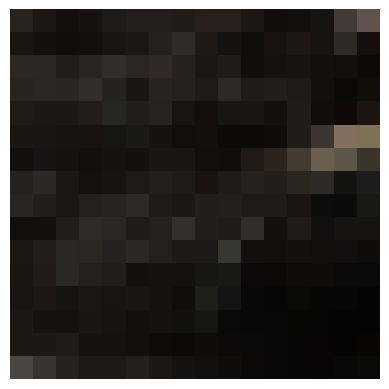

Sample HR image:


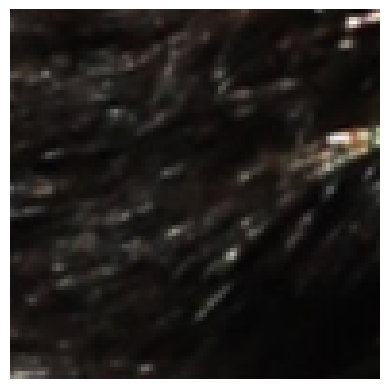

In [8]:
# =============================================================================
# Create Datasets and DataLoaders
# =============================================================================

from torch.utils.data import DataLoader

# Create datasets using config values (no need to pass args, they use cfg defaults)
train_dataset = DIV2KDataset(TRAIN_IMAGE_PATH)
test_dataset = DIV2KDataset(EVAL_IMAGE_PATH)

# Create data loaders with config values
train_loader = DataLoader(
    train_dataset, 
    batch_size=cfg.batch_size, 
    shuffle=True, 
    num_workers=cfg.num_workers, 
    pin_memory=True, 
    persistent_workers=True, 
    prefetch_factor=cfg.prefetch_factor
)
test_loader = DataLoader(
    test_dataset, 
    batch_size=cfg.batch_size, 
    shuffle=False, 
    num_workers=cfg.num_workers, 
    pin_memory=True, 
    persistent_workers=True, 
    prefetch_factor=cfg.prefetch_factor
)

# Verify dataset and show sample
print(f"Training samples: {len(train_dataset)}")
print(f"Test samples:     {len(test_dataset)}")

sample_lr, sample_hr = next(iter(train_loader))
print(f"\nBatch shapes:")
print(f"  LR: {sample_lr.shape} (batch, channels, {cfg.lr_crop_size}, {cfg.lr_crop_size})")
print(f"  HR: {sample_hr.shape} (batch, channels, {cfg.hr_crop_size}, {cfg.hr_crop_size})")

# Show first sample from batch
print("\nSample LR image:")
show_image(sample_lr[0])
print("Sample HR image:")
show_image(sample_hr[0])

In [9]:
# =============================================================================
# Model Definitions
# =============================================================================

from typing import Any
import torch
from torch.nn import Flatten, Linear, ReLU, Sequential, Conv2d, PixelShuffle

# Constants for RGB images
RGB_CHANNELS = 3
CONV_KERNEL_SIZE = 3


def count_parameters(model: nn.Module) -> int:
    """Count trainable parameters in a model."""
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


class SimpleModel(nn.Module):
    """Simple MLP-based upscaling model (baseline, not recommended for production)."""
    
    HIDDEN_DIM_1 = 1024
    HIDDEN_DIM_2 = 4096
    
    def __init__(self, in_features: int = None, out_features: int = None, out_shape: tuple = None):
        super().__init__()
        
        # Calculate default dimensions from config
        if in_features is None:
            in_features = RGB_CHANNELS * cfg.lr_crop_size * cfg.lr_crop_size
        if out_features is None:
            out_features = RGB_CHANNELS * cfg.hr_crop_size * cfg.hr_crop_size
        if out_shape is None:
            out_shape = (RGB_CHANNELS, cfg.hr_crop_size, cfg.hr_crop_size)
            
        self.out_shape = out_shape

        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features, self.HIDDEN_DIM_1),
            nn.ReLU(),
            nn.Linear(self.HIDDEN_DIM_1, self.HIDDEN_DIM_2),
            nn.ReLU(),
            nn.Linear(self.HIDDEN_DIM_2, out_features)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.net(x)
        x = x.view(x.size(0), *self.out_shape)
        return x


# =============================================================================
# Core Building Blocks
# =============================================================================

class ResidualBlock(nn.Module):
    """Standard residual block with two 3x3 convolutions."""
    
    def __init__(self, channels: int):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(channels, channels, kernel_size=CONV_KERNEL_SIZE, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(channels, channels, kernel_size=CONV_KERNEL_SIZE, padding=1),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return x + self.block(x)


class UpsampleBlock(nn.Module):
    """Pixel shuffle upsampling block for super-resolution."""
    
    def __init__(self, channels: int, scale: int = None):
        super().__init__()
        if scale is None:
            scale = cfg.scale_factor
        self.conv = nn.Conv2d(channels, channels * (scale ** 2), kernel_size=CONV_KERNEL_SIZE, padding=1)
        self.pixel_shuffle = nn.PixelShuffle(scale)
        self.to_rgb = nn.Conv2d(channels, RGB_CHANNELS, kernel_size=CONV_KERNEL_SIZE, padding=1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.to_rgb(self.pixel_shuffle(self.conv(x)))


class SimpleSRCNN(nn.Module):
    """Simple SRCNN with residual blocks and pixel shuffle upsampling."""
    
    def __init__(
        self, 
        scale: int = None, 
        channels: int = None, 
        num_blocks: int = None
    ):
        super().__init__()
        
        # Use config defaults
        if scale is None:
            scale = cfg.scale_factor
        if channels is None:
            channels = cfg.model_channels
        if num_blocks is None:
            num_blocks = cfg.num_residual_blocks
            
        self.head = nn.Conv2d(RGB_CHANNELS, channels, kernel_size=CONV_KERNEL_SIZE, padding=1)

        self.body = nn.Sequential(
            *[ResidualBlock(channels) for _ in range(num_blocks)]
        )

        self.body_conv = nn.Conv2d(channels, channels, kernel_size=CONV_KERNEL_SIZE, padding=1)
        self.upsample = UpsampleBlock(channels, scale)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        features = self.head(x)
        residual = self.body(features)
        residual = self.body_conv(residual)
        features = features + residual
        return self.upsample(features)









class BilinearUpsample(nn.Module):
    """Bilinear interpolation upsampling layer."""
    
    def __init__(self, scale: int = None):
        super().__init__()
        self.scale = scale if scale is not None else cfg.scale_factor

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return F.interpolate(
            x,
            scale_factor=self.scale,
            mode='bilinear',
            align_corners=False
        )


class UpsampleFirstSRCNN(nn.Module):
    """SRCNN that upsamples first using bilinear, then refines with convolutions."""
    
    def __init__(
        self, 
        scale: int = None, 
        channels: int = None, 
        num_blocks: int = None
    ):
        super().__init__()
        
        # Use config defaults
        if scale is None:
            scale = cfg.scale_factor
        if channels is None:
            channels = cfg.model_channels
        if num_blocks is None:
            num_blocks = cfg.num_residual_blocks
            
        self.upsample = BilinearUpsample(scale)
        self.head = nn.Conv2d(RGB_CHANNELS, channels, kernel_size=CONV_KERNEL_SIZE, padding=1)

        self.body = nn.Sequential(
            *[ResidualBlock(channels) for _ in range(num_blocks)]
        )

        self.body_conv = nn.Conv2d(channels, channels, kernel_size=CONV_KERNEL_SIZE, padding=1)

        self.to_rgb = nn.Sequential(
            nn.Conv2d(channels, channels, kernel_size=CONV_KERNEL_SIZE, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(channels, RGB_CHANNELS, kernel_size=CONV_KERNEL_SIZE, padding=1),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # Upsample LR to HR size using bilinear interpolation
        base = self.upsample(x)  # [B, 3, H*scale, W*scale]

        # Extract and refine features
        features = self.head(base)           # [B, C, H*scale, W*scale]
        residual = self.body(features)       # [B, C, H*scale, W*scale]
        residual = self.body_conv(residual)  # [B, C, H*scale, W*scale]

        features = features + residual       # Global residual connection
        refinement = self.to_rgb(features)   # [B, 3, H*scale, W*scale]

        return base + refinement    
    



import torch
import torch.nn as nn
import torch.nn.functional as F


class ConvExpert(nn.Module):
    """
    One convolution expert.
    """
    def __init__(self, in_channels: int, out_channels: int, kernel_size: int):
        super().__init__()
        self.conv = nn.Conv2d(
            in_channels,
            out_channels,
            kernel_size=kernel_size,
            padding=kernel_size // 2
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.conv(x)


class Router(nn.Module):
    """
    Produces expert weights from the input.
    Uses global average pooling so each image gets one routing vector.
    """
    def __init__(self, in_channels: int, num_experts: int, hidden_dim: int | None = None):
        super().__init__()

        if hidden_dim is None:
            hidden_dim = max(in_channels // 4, 8)

        self.net = nn.Sequential(
            nn.Linear(in_channels, hidden_dim),
            nn.ReLU(inplace=True),
            nn.Linear(hidden_dim, num_experts)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        x: [B, C, H, W]
        returns: [B, num_experts]
        """
        pooled = x.mean(dim=(2, 3))          # [B, C]
        logits = self.net(pooled)            # [B, E]
        weights = F.softmax(logits, dim=-1)  # [B, E]
        return weights


class MoeConv(nn.Module):
    """
    Mixture of convolution experts.
    """
    def __init__(self, in_channels: int, out_channels: int, kernel_size: int, num_experts: int):
        super().__init__()
        self.num_experts = num_experts

        self.router = Router(in_channels, num_experts)

        self.experts = nn.ModuleList([
            ConvExpert(in_channels, out_channels, kernel_size)
            for _ in range(num_experts)
        ])

    def forward(self, x: torch.Tensor, return_weights: bool = False):
        weights = self.router(x)  # [B, E]

        expert_outputs = [expert(x) for expert in self.experts]
        expert_outputs = torch.stack(expert_outputs, dim=1)
        # [B, E, out_channels, H, W]

        out = (weights[:, :, None, None, None] * expert_outputs).sum(dim=1)
        # [B, out_channels, H, W]

        if return_weights:
            return out, weights
        return out

import math
import torch
import torch.nn as nn
import torch.nn.functional as F


def gaussian_kernel2d(kernel_size: int, sigma: float, device=None, dtype=None):
    """
    Create a 2D Gaussian kernel.
    """
    ax = torch.arange(kernel_size, device=device, dtype=dtype) - (kernel_size - 1) / 2
    xx, yy = torch.meshgrid(ax, ax, indexing="ij")
    kernel = torch.exp(-(xx**2 + yy**2) / (2 * sigma**2))
    kernel = kernel / kernel.sum()
    return kernel


import math
import torch
import torch.nn as nn
import torch.nn.functional as F


import math
import torch
import torch.nn as nn
import torch.nn.functional as F


class UnsharpMaskLayer(nn.Module):
    """
    Differentiable unsharp-mask-like sharpening layer for tensors.

    - radius is fixed
    - threshold is fixed
    - percent is trainable
    - uses soft-thresholding instead of hard masking
    """
    def __init__(
        self,
        radius: float = 1.2,
        percent: float = 130.0,
        threshold: float = 2.0,
    ):
        super().__init__()

        self.register_buffer("radius", torch.tensor(float(radius)))
        self.register_buffer("threshold", torch.tensor(float(threshold)))

        # only this is trainable
        self.percent = nn.Parameter(torch.tensor(float(percent)))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        x expected in [0, 1], shape [B, C, H, W]
        """
        if x.ndim != 4:
            raise ValueError(f"Expected [B, C, H, W], got {x.shape}")

        _, c, _, _ = x.shape

        radius = torch.clamp(self.radius, min=0.1)
        percent = torch.clamp(self.percent, min=0.0)
        threshold = torch.clamp(self.threshold, min=0.0)

        amount = percent / 100.0
        thresh = threshold / 255.0

        sigma = radius.item()
        kernel_size = max(3, int(2 * math.ceil(3 * sigma) + 1))
        if kernel_size % 2 == 0:
            kernel_size += 1

        kernel = gaussian_kernel2d(
            kernel_size=kernel_size,
            sigma=sigma,
            device=x.device,
            dtype=x.dtype,
        )
        kernel = kernel.view(1, 1, kernel_size, kernel_size).repeat(c, 1, 1, 1)

        # blur each channel independently
        blurred = F.conv2d(x, kernel, padding=kernel_size // 2, groups=c)

        # detail / high-frequency component
        detail = x - blurred

        # soft-threshold instead of hard mask
        soft_detail = torch.sign(detail) * F.relu(detail.abs() - thresh)

        # add back sharpened detail
        out = x + amount * soft_detail

        return out.clamp(0.0, 1.0)


# =============================================================================
# MoE Sharpening Layer
# =============================================================================

class SharpeningExpert(nn.Module):
    """
    A single sharpening expert with fixed radius/threshold and trainable percent.
    Each expert specializes in a different type of sharpening.
    """
    
    def __init__(self, radius: float, percent: float, threshold: float):
        super().__init__()
        self.register_buffer("radius", torch.tensor(float(radius)))
        self.register_buffer("threshold", torch.tensor(float(threshold)))
        self.percent = nn.Parameter(torch.tensor(float(percent)))
        
        # Pre-compute kernel size from radius
        sigma = max(0.1, radius)
        self.kernel_size = max(3, int(2 * math.ceil(3 * sigma) + 1))
        if self.kernel_size % 2 == 0:
            self.kernel_size += 1
    
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """Apply unsharp mask sharpening."""
        batch_size, num_channels, height, width = x.shape
        
        radius = torch.clamp(self.radius, min=0.1)
        percent = torch.clamp(self.percent, min=0.0)
        threshold = torch.clamp(self.threshold, min=0.0)
        
        amount = percent / 100.0
        thresh = threshold / 255.0
        
        # Create Gaussian blur kernel
        kernel = gaussian_kernel2d(
            kernel_size=self.kernel_size,
            sigma=radius.item(),
            device=x.device,
            dtype=x.dtype,
        )
        kernel = kernel.view(1, 1, self.kernel_size, self.kernel_size).repeat(num_channels, 1, 1, 1)
        
        # Apply blur
        blurred = F.conv2d(x, kernel, padding=self.kernel_size // 2, groups=num_channels)
        
        # Extract high-frequency detail
        detail = x - blurred
        
        # Soft-threshold the detail
        soft_detail = torch.sign(detail) * F.relu(detail.abs() - thresh)
        
        # Add sharpened detail back
        sharpened = x + amount * soft_detail
        
        return sharpened.clamp(0.0, 1.0)


class SharpeningRouter(nn.Module):
    """
    Routes images to different sharpening experts based on image content.
    Uses global average pooling to analyze the image characteristics.
    """
    
    def __init__(self, in_channels: int, num_experts: int, hidden_dim: int = 32):
        super().__init__()
        self.num_experts = num_experts
        
        # Small CNN to extract routing features
        self.feature_extractor = nn.Sequential(
            nn.Conv2d(in_channels, hidden_dim, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d(1),  # Global average pool
            nn.Flatten(),
        )
        
        # Router MLP
        self.router = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(inplace=True),
            nn.Linear(hidden_dim, num_experts),
        )
    
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Compute routing weights for each image in the batch.
        
        Args:
            x: Input tensor [B, C, H, W]
            
        Returns:
            Routing weights [B, num_experts] (softmax normalized)
        """
        features = self.feature_extractor(x)  # [B, hidden_dim]
        logits = self.router(features)        # [B, num_experts]
        weights = F.softmax(logits, dim=-1)   # [B, num_experts]
        return weights


class MoEUnsharpMaskLayer(nn.Module):
    """
    Mixture of Experts sharpening layer.
    
    Each expert is a different sharpener with unique radius/percent/threshold.
    A router network learns to blend experts based on image content:
    - Some images need subtle sharpening (low percent, small radius)
    - Some need aggressive sharpening (high percent, larger radius)
    - Some have fine detail needing careful threshold control
    """
    
    def __init__(
        self, 
        num_experts: int = None,
        expert_configs: list = None,
        in_channels: int = RGB_CHANNELS,
    ):
        super().__init__()
        
        if num_experts is None:
            num_experts = cfg.sharpen_num_experts
            
        # Use provided configs, config defaults, or generate interpolated configs
        if expert_configs is None:
            if len(cfg.sharpen_expert_configs) == num_experts:
                # Use config defaults directly
                expert_configs = list(cfg.sharpen_expert_configs)
            else:
                # Generate interpolated configs for the requested number of experts
                expert_configs = self._generate_expert_configs(num_experts)
        
        self.num_experts = num_experts
        
        # Create sharpening experts
        self.experts = nn.ModuleList([
            SharpeningExpert(radius=r, percent=p, threshold=t)
            for r, p, t in expert_configs
        ])
        
        # Create router
        self.router = SharpeningRouter(
            in_channels=in_channels, 
            num_experts=num_experts
        )
    
    def _generate_expert_configs(self, num_experts: int) -> list:
        """Generate expert configurations spanning subtle to aggressive sharpening."""
        configs = []
        for i in range(num_experts):
            # Interpolate between subtle and aggressive
            t = i / max(1, num_experts - 1)  # 0 to 1
            
            radius = 0.5 + t * 2.0           # 0.5 to 2.5
            percent = 50.0 + t * 200.0       # 50 to 250
            threshold = 1.0 + t * 4.0        # 1 to 5
            
            configs.append((radius, percent, threshold))
        
        return configs
    
    def forward(self, x: torch.Tensor, return_weights: bool = False):
        """
        Apply MoE sharpening.
        
        Args:
            x: Input tensor [B, C, H, W]
            return_weights: If True, also return router weights
            
        Returns:
            Sharpened tensor [B, C, H, W]
            (optional) Router weights [B, num_experts]
        """
        if x.ndim != 4:
            raise ValueError(f"Expected [B, C, H, W], got {x.shape}")
        
        # Get routing weights for each image
        weights = self.router(x)  # [B, num_experts]
        
        # Apply each expert and blend based on weights
        expert_outputs = []
        for expert in self.experts:
            expert_out = expert(x)  # [B, C, H, W]
            expert_outputs.append(expert_out)
        
        # Stack: [B, num_experts, C, H, W]
        expert_outputs = torch.stack(expert_outputs, dim=1)
        
        # Weighted sum: weights [B, E, 1, 1, 1] * outputs [B, E, C, H, W]
        weights_expanded = weights[:, :, None, None, None]
        output = (weights_expanded * expert_outputs).sum(dim=1)  # [B, C, H, W]
        
        if return_weights:
            return output, weights
        return output


class BilinearSkipPixelShuffleSRCNN(nn.Module):
    """
    Main super-resolution model with:
    - Bilinear upsampling skip connection
    - Mixture of Experts (MoE) convolution layers
    - Pixel shuffle upsampling
    - Optional refinement and sharpening layers
    """
    
    def __init__(
        self,
        scale: int = None,
        channels: int = None,
        num_blocks: int = None,
        final_refine: bool = None,
        use_sharpen: bool = None,
        sharpen_radius: float = None,
        sharpen_percent: float = None,
        sharpen_threshold: float = None,
        # MoE parameters
        moe_kernel_size: int = None,
        moe_num_experts_head1: int = None,
        moe_num_experts_head2: int = None,
        # Refinement parameters
        refine_intermediate_channels: int = None,
        # MoE sharpening parameters
        use_moe_sharpen: bool = None,
        sharpen_num_experts: int = None,
    ):
        super().__init__()
        
        # Use config defaults for all parameters
        if scale is None:
            scale = cfg.scale_factor
        if channels is None:
            channels = cfg.model_channels
        if num_blocks is None:
            num_blocks = cfg.num_residual_blocks
        if final_refine is None:
            final_refine = cfg.use_final_refine
        if use_sharpen is None:
            use_sharpen = cfg.use_sharpen
        if sharpen_radius is None:
            sharpen_radius = cfg.sharpen_radius
        if sharpen_percent is None:
            sharpen_percent = cfg.sharpen_percent
        if sharpen_threshold is None:
            sharpen_threshold = cfg.sharpen_threshold
        if moe_kernel_size is None:
            moe_kernel_size = cfg.moe_kernel_size
        if moe_num_experts_head1 is None:
            moe_num_experts_head1 = cfg.moe_num_experts_head1
        if moe_num_experts_head2 is None:
            moe_num_experts_head2 = cfg.moe_num_experts_head2
        if refine_intermediate_channels is None:
            refine_intermediate_channels = refine_intermediate_channels
        if use_moe_sharpen is None:
            use_moe_sharpen = cfg.use_moe_sharpen
        if sharpen_num_experts is None:
            sharpen_num_experts = cfg.sharpen_num_experts
            
        self.bilinear = BilinearUpsample(scale)

        # MoE head layers
        self.head_moe1 = MoeConv(
            RGB_CHANNELS, channels, 
            kernel_size=moe_kernel_size, 
            num_experts=moe_num_experts_head1
        )
        self.head_act = nn.ReLU(inplace=True)
        self.head_moe2 = MoeConv(
            channels, channels, 
            kernel_size=moe_kernel_size, 
            num_experts=moe_num_experts_head2
        )

        # Residual body
        self.body = nn.Sequential(
            *[ResidualBlock(channels) for _ in range(num_blocks)]
        )
        self.body_conv = nn.Conv2d(channels, channels, kernel_size=CONV_KERNEL_SIZE, padding=1)

        # Upsampling
        self.upsample = UpsampleBlock(channels, scale)

        # Learnable blend parameter (sigmoid applied in forward)
        self.alpha_logit = nn.Parameter(torch.tensor(0.0))

        # Optional refinement layer
        self.final_refine = final_refine
        if final_refine:
            self.refine = nn.Sequential(
                nn.Conv2d(RGB_CHANNELS, refine_intermediate_channels, kernel_size=CONV_KERNEL_SIZE, padding=1),
                nn.ReLU(inplace=True),
                nn.Conv2d(refine_intermediate_channels, RGB_CHANNELS, kernel_size=CONV_KERNEL_SIZE, padding=1)
            )

        # Optional sharpening layer (MoE or single)
        self.use_sharpen = use_sharpen
        self.use_moe_sharpen = use_moe_sharpen if use_sharpen else False
        
        if use_sharpen:
            if self.use_moe_sharpen:
                # MoE sharpening with multiple expert sharpeners
                self.sharpen = MoEUnsharpMaskLayer(
                    num_experts=sharpen_num_experts,
                    in_channels=RGB_CHANNELS,
                )
            else:
                # Single sharpening layer (legacy)
                self.sharpen = UnsharpMaskLayer(
                    radius=sharpen_radius,
                    percent=sharpen_percent,
                    threshold=sharpen_threshold,
                )

    def forward(self, lr_input: torch.Tensor, return_router_weights: bool = False):
        router_weights_list = []

        # Bilinear baseline (skip connection)
        bilinear_hr = self.bilinear(lr_input)

        # MoE feature extraction (on LR input)
        features, moe_weights_1 = self.head_moe1(lr_input, return_weights=True)
        router_weights_list.append(moe_weights_1)

        features = self.head_act(features)

        features, moe_weights_2 = self.head_moe2(features, return_weights=True)
        router_weights_list.append(moe_weights_2)

        # Residual body
        residual = self.body(features)
        residual = self.body_conv(residual)
        features = features + residual

        # Pixel shuffle upsampling
        learned_hr = self.upsample(features)

        # Blend bilinear and learned HR with learnable alpha
        blend_alpha = torch.sigmoid(self.alpha_logit)
        output = bilinear_hr + (blend_alpha * learned_hr)

        # Optional post-processing
        if self.final_refine:
            output = self.refine(output)

        if self.use_sharpen:
            if self.use_moe_sharpen and return_router_weights:
                # Get sharpening weights for analysis
                output, sharpen_weights = self.sharpen(output, return_weights=True)
                router_weights_list.append(sharpen_weights)
            else:
                output = self.sharpen(output)

        if return_router_weights:
            return output, router_weights_list
        return output


def build_model_from_config(config: Config, device: torch.device = None) -> BilinearSkipPixelShuffleSRCNN:
    """
    Build a model instance from a Config object.
    
    This function explicitly passes all config values to the model,
    so it works correctly with loaded configs (not just the global cfg).
    
    Args:
        config: Config object with model hyperparameters
        device: Torch device to place the model on
        
    Returns:
        Initialized model moved to the specified device
    """
    model = BilinearSkipPixelShuffleSRCNN(
        scale=config.scale_factor,
        channels=config.model_channels,
        num_blocks=config.num_residual_blocks,
        final_refine=config.use_final_refine,
        use_sharpen=config.use_sharpen,
        sharpen_radius=config.sharpen_radius,
        sharpen_percent=config.sharpen_percent,
        sharpen_threshold=config.sharpen_threshold,
        # MoE parameters
        moe_kernel_size=config.moe_kernel_size,
        moe_num_experts_head1=config.moe_num_experts_head1,
        moe_num_experts_head2=config.moe_num_experts_head2,
        # Refinement parameters
        refine_intermediate_channels=config.refine_intermediate_channels,
        # MoE sharpening parameters
        use_moe_sharpen=config.use_moe_sharpen,
        sharpen_num_experts=config.sharpen_num_experts,
    )
    
    if device is not None:
        model = model.to(device)
    
    return model

In [ ]:
# =============================================================================
# Training Setup and Execution
# =============================================================================

import torch.optim as optim

# ----- Device -----
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training on: {device}")

# =============================================================================
# ⚠️ SET MODEL NAME - Change this for each experiment!
# =============================================================================
cfg.model_name = "srcnn_scale6_v1"  # <-- CHANGE THIS for each training run!
# =============================================================================

print(f"\n{'='*60}")
print(f"📦 MODEL: {cfg.model_name}")
print(f"{'='*60}")
print(f"Model folder:    {cfg.model_folder}")
print(f"Config path:     {cfg.config_path}")
print(f"Best model:      {cfg.best_model_path}")
print(f"Final model:     {cfg.final_model_path}")
print(f"{'='*60}\n")

# ----- Create Model -----
# Model uses config defaults (channels, num_blocks, scale, etc.)
model = build_model_from_config(cfg, device)
print(f"Model parameters: {count_parameters(model):,}")

# ----- Loss and Optimizer -----
criterion = nn.L1Loss()
optimizer = torch.optim.AdamW(
    model.parameters(), 
    lr=cfg.learning_rate, 
    weight_decay=cfg.weight_decay
)

# ----- Show GPU Info -----
!nvidia-smi

# ----- Train (config.json is saved automatically at start) -----
history = train_and_log(
    model=model, 
    trainloader=train_loader, 
    testloader=test_loader, 
    criterion=criterion, 
    optimizer=optimizer,
    epochs=cfg.num_epochs, 
    device=device,
    config=cfg
)

# ----- Save Final Model -----
torch.save(model.state_dict(), cfg.final_model_path)
print(f"Final model saved to: {cfg.final_model_path}")

# Show what's in the model folder
print(f"\n📁 Contents of {cfg.model_folder}:")
for f in os.listdir(cfg.model_folder):
    print(f"   - {f}")







Training on: cuda
The training configs are: Config(scale_factor=6, hr_crop_size=96, batch_size=256, num_workers=12, prefetch_factor=12, rotation_prob=0.5, flip_prob=0.5, model_channels=128, num_residual_blocks=32, moe_kernel_size=5, moe_num_experts_head1=24, moe_num_experts_head2=16, refine_intermediate_channels=16, sharpen_radius=1.2, sharpen_percent=130.0, sharpen_threshold=2.0, use_sharpen=True, use_final_refine=True, sharpen_num_experts=4, use_moe_sharpen=True, sharpen_expert_configs=((0.5, 50.0, 1.0), (1.0, 100.0, 2.0), (1.5, 150.0, 3.0), (2.0, 200.0, 4.0)), learning_rate=0.0001, weight_decay=0.0001, num_epochs=120, importance_loss_weight=0.01, checkpoint_every_n_epochs=10, save_best_only=True, keep_last_n_checkpoints=3, inference_patch_size=32, inference_stride=16, eps=1e-08, blend_window_eps=0.001, drive_base_path='drive/MyDrive/upscaler/', models_subdir='models/')
Model will be saved to: drive/MyDrive/upscaler/models/
Model parameters: 21,706,439
Mon Mar 16 05:44:27 2026       

Epoch 1/120 [train]:   0%|          | 0/33 [08:57<?, ?it/s]

Epoch 1/120 [val]:   0%|          | 0/4 [00:00<?, ?it/s]

Epoch   1/120 | Train Loss 0.288101 PSNR 8.45 dB | Val Loss 0.208293 PSNR 9.86 dB | LR 0.000100
RAM: 3.7%
GPU allocated: 0.34 GB | reserved: 10.88 GB
  ✓ New best model saved (val_loss: 0.208293)


Epoch 2/120 [train]:   0%|          | 0/33 [00:00<?, ?it/s]

...

Epoch 119/120 [val]:   0%|          | 0/4 [00:00<?, ?it/s]

Epoch 119/120 | Train Loss 0.028344 PSNR 25.54 dB | Val Loss 0.021562 PSNR 28.02 dB | LR 0.000100
RAM: 4.1%
GPU allocated: 0.34 GB | reserved: 10.88 GB


Epoch 120/120 [train]:   0%|          | 0/33 [00:00<?, ?it/s]

Epoch 120/120 [val]:   0%|          | 0/4 [00:00<?, ?it/s]

Epoch 120/120 | Train Loss 0.027265 PSNR 25.71 dB | Val Loss 0.020950 PSNR 28.43 dB | LR 0.000100
RAM: 4.2%
GPU allocated: 0.34 GB | reserved: 10.88 GB
  ✓ Checkpoint saved: srcnn_ch128_blk32_scale6_sharpenTrue_epoch120.pth

Training complete! Best model at epoch 102 (val_loss: 0.019756)
Best model saved to: drive/MyDrive/upscaler/models/srcnn_ch128_blk32_scale6_sharpenTrue_best.pth
Final model saved to: drive/MyDrive/upscaler/models/srcnn_ch128_blk32_scale6_sharpenTrue.pth

📁 Contents of drive/MyDrive/upscaler/models/:
   - srcnn_ch128_blk32_scale4_sharpenTrue_epoch025.pth
   - srcnn_ch128_blk32_scale4_sharpenTrue_epoch010.pth
   - srcnn_ch128_blk32_scale4_sharpenTrue_epoch020.pth
   - srcnn_ch128_blk32_scale4_sharpenTrue_best.pth
   - IMG_7183 2.png
   - IMG_8256 2.png
   - IMG_7349 2.png
   - IMG_3362 2.png
   - IMG_7785 2.png
   - IMG_7518 2.png
   - IMG_8335 2.png
   - IMG_8235 2.png
   - IMG_7577 2.png
   - IMG_7191 2.png
   - IMG_8239 2.png
   - IMG_3370 2.png
   - IMG_7338 2.pn

In [11]:
# Cell kept for backwards compatibility - saving is now handled at end of training cell above
# You can delete this cell if not needed

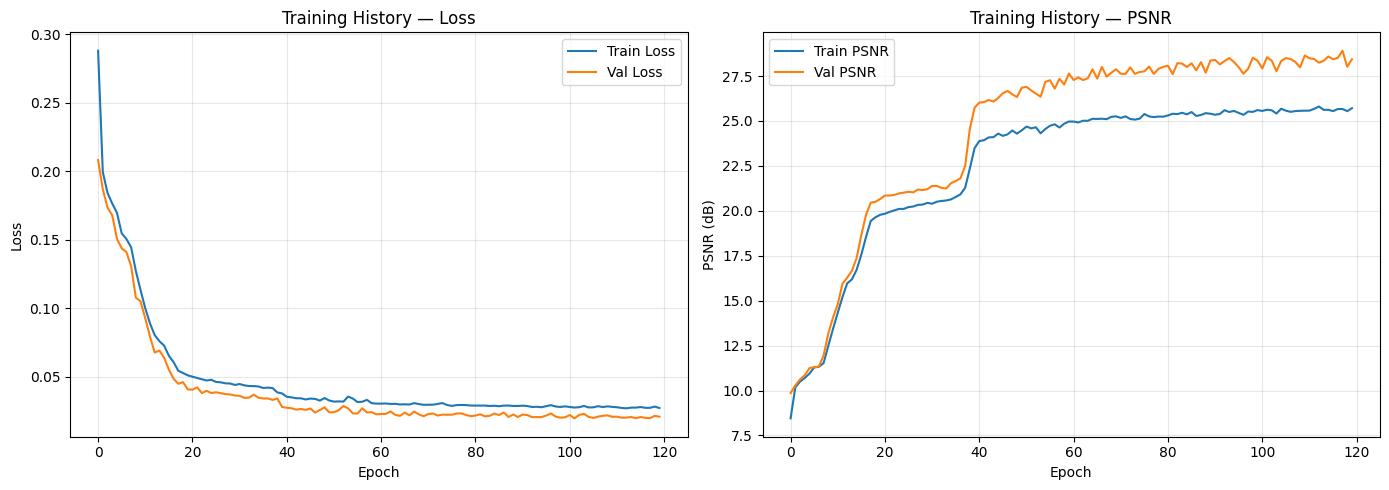

Sample 89:
  LR shape: torch.Size([3, 16, 16])
  SR shape: torch.Size([3, 96, 96])
  HR shape: torch.Size([3, 96, 96])


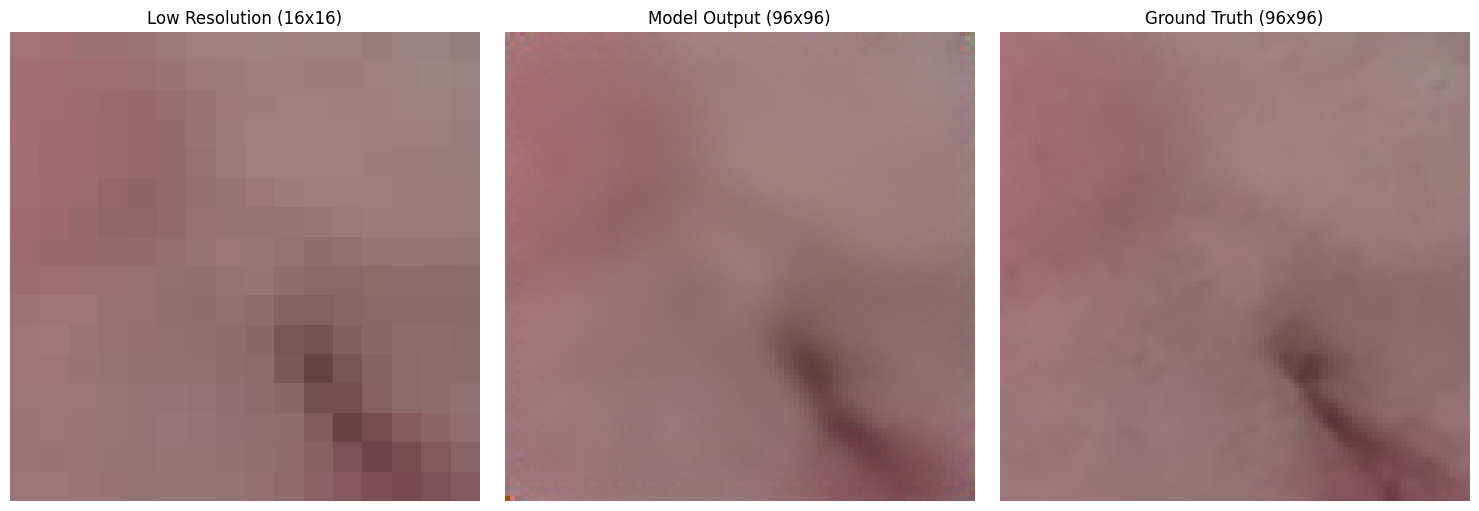

In [12]:
# =============================================================================
# Visualize Training Results
# =============================================================================

import matplotlib.pyplot as plt
import torchvision.transforms.functional as TF

# ----- Plot Training History -----
plot_history(history)

# ----- Visualize a Sample Prediction -----
SAMPLE_INDEX = 89  # Index into test dataset for visualization

sample_lr, sample_hr = test_dataset[SAMPLE_INDEX]
sample_sr = run_model_on_tensor(model, sample_lr, device)

print(f"Sample {SAMPLE_INDEX}:")
print(f"  LR shape: {sample_lr.shape}")
print(f"  SR shape: {sample_sr.shape}")
print(f"  HR shape: {sample_hr.shape}")

# Convert tensors to PIL for display
lr_pil = TF.to_pil_image(sample_lr)
sr_pil = TF.to_pil_image(sample_sr.clamp(0, 1))
hr_pil = TF.to_pil_image(sample_hr)

# Display side-by-side comparison
COMPARISON_FIGSIZE = (15, 5)

plt.figure(figsize=COMPARISON_FIGSIZE)

plt.subplot(1, 3, 1)
plt.imshow(lr_pil)
plt.title(f"Low Resolution ({cfg.lr_crop_size}x{cfg.lr_crop_size})")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(sr_pil)
plt.title(f"Model Output ({cfg.hr_crop_size}x{cfg.hr_crop_size})")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(hr_pil)
plt.title(f"Ground Truth ({cfg.hr_crop_size}x{cfg.hr_crop_size})")
plt.axis("off")

plt.tight_layout()
plt.show()

In [13]:
# =============================================================================
# Image Reconstruction (Patch-based Inference)
# =============================================================================

import torch
import torch.nn as nn
from PIL import Image
from torchvision import transforms
from typing import Union


def make_blend_window(size: int, device: str, eps: float = None) -> torch.Tensor:
    """
    Create a 2D Hann-like blending window for smooth patch blending.
    
    Args:
        size: Window size (typically sr_patch_size)
        device: Torch device
        eps: Minimum value to avoid zeros at borders
    
    Returns:
        2D weight tensor of shape [size, size]
    """
    if eps is None:
        eps = cfg.blend_window_eps
    window_1d = torch.hann_window(size, periodic=False, device=device)
    window_1d = torch.clamp(window_1d, min=eps)
    window_2d = torch.outer(window_1d, window_1d)
    return window_2d


def reconstruct_image(
    model: nn.Module,
    lr_image: Union[torch.Tensor, Image.Image],
    patch_size: int = None,
    stride: int = None,
    scale: int = None,
    device: str = "cuda",
    debug_patches: bool = False,
) -> torch.Tensor:
    """
    Reconstruct a full super-resolved image using overlapping LR patches
    with weighted blending to reduce grid/seam artifacts.
    
    Args:
        model: Trained super-resolution model
        lr_image: Low-resolution input image (PIL or tensor)
        patch_size: Size of LR patches (default from config)
        stride: Step between patches (default from config)
        scale: Upscaling factor (default from config)
        device: Torch device for computation
        debug_patches: If True, display each patch during processing
    
    Returns:
        Super-resolved image tensor of shape [C, H*scale, W*scale]
    """
    # Use config defaults
    if patch_size is None:
        patch_size = cfg.inference_patch_size
    if stride is None:
        stride = cfg.inference_stride
    if scale is None:
        scale = cfg.scale_factor

    model = model.to(device)
    model.eval()

    # Convert PIL -> tensor
    if isinstance(lr_image, Image.Image):
        lr_image = lr_image.convert("RGB")
        lr_image = transforms.ToTensor()(lr_image)

    if not isinstance(lr_image, torch.Tensor):
        raise TypeError("lr_image must be a torch.Tensor or PIL.Image.Image")

    if lr_image.ndim != 3:
        raise ValueError(f"Expected lr_image shape [C, H, W], got {lr_image.shape}")

    num_channels, lr_height, lr_width = lr_image.shape

    if lr_height < patch_size or lr_width < patch_size:
        raise ValueError(
            f"Image size ({lr_height}, {lr_width}) must be at least patch_size ({patch_size})"
        )

    lr_image = lr_image.to(device)

    # Calculate HR dimensions
    hr_height = lr_height * scale
    hr_width = lr_width * scale
    sr_patch_size = patch_size * scale

    # Accumulators for weighted blending
    sr_accumulator = torch.zeros(num_channels, hr_height, hr_width, device=device)
    weight_accumulator = torch.zeros(num_channels, hr_height, hr_width, device=device)

    # Smooth blending weight for each SR patch
    blend_weight_2d = make_blend_window(sr_patch_size, device=device)
    blend_weight_3d = blend_weight_2d.unsqueeze(0).expand(num_channels, -1, -1)

    def process_patch(lr_y: int, lr_x: int):
        """Process a single LR patch and accumulate into SR image."""
        # Extract LR patch and run through model
        lr_patch = lr_image[:, lr_y:lr_y + patch_size, lr_x:lr_x + patch_size].unsqueeze(0)
        sr_patch = model(lr_patch).squeeze(0)  # [C, sr_patch_size, sr_patch_size]
        
        # Optional debug visualization
        if debug_patches:
            plt.figure(figsize=(10, 5))
            plt.subplot(1, 2, 1)
            lr_display = lr_patch.squeeze(0).permute(1, 2, 0).detach().cpu().clamp(0, 1)
            plt.imshow(lr_display)
            plt.title(f"LR patch @ ({lr_y}, {lr_x})")
            plt.axis("off")
            plt.subplot(1, 2, 2)
            sr_display = sr_patch.permute(1, 2, 0).detach().cpu().clamp(0, 1)
            plt.imshow(sr_display)
            plt.title("SR patch")
            plt.axis("off")
            plt.show()

        # Map to HR coordinates
        sr_y = lr_y * scale
        sr_x = lr_x * scale

        # Accumulate with blending weights
        sr_accumulator[:, sr_y:sr_y + sr_patch_size, sr_x:sr_x + sr_patch_size] += sr_patch * blend_weight_3d
        weight_accumulator[:, sr_y:sr_y + sr_patch_size, sr_x:sr_x + sr_patch_size] += blend_weight_3d

    with torch.no_grad():
        # Process main grid of patches
        for lr_y in range(0, lr_height - patch_size + 1, stride):
            for lr_x in range(0, lr_width - patch_size + 1, stride):
                process_patch(lr_y, lr_x)

        # Handle bottom edge if not covered
        if (lr_height - patch_size) % stride != 0:
            lr_y = lr_height - patch_size
            for lr_x in range(0, lr_width - patch_size + 1, stride):
                process_patch(lr_y, lr_x)

        # Handle right edge if not covered
        if (lr_width - patch_size) % stride != 0:
            lr_x = lr_width - patch_size
            for lr_y in range(0, lr_height - patch_size + 1, stride):
                process_patch(lr_y, lr_x)

        # Handle bottom-right corner if not covered
        if (lr_height - patch_size) % stride != 0 and (lr_width - patch_size) % stride != 0:
            process_patch(lr_height - patch_size, lr_width - patch_size)

    # Normalize by accumulated weights
    sr_image = sr_accumulator / weight_accumulator.clamp(min=cfg.eps)
    return sr_image.clamp(0, 1)


In [16]:
# =============================================================================
# Inference: Load Model and Upscale an Image
# =============================================================================

import torch
from PIL import Image
from torchvision.transforms.functional import to_pil_image

# =============================================================================
# ⚠️ SET MODEL NAME - Which trained model to load?
# =============================================================================
MODEL_NAME = "srcnn_scale6_v1"  # <-- Change this to load a different model
USE_BEST_CHECKPOINT = True      # True = load best.pth, False = load final.pth
# =============================================================================

# ----- Load config from model folder -----
model_folder = f"{cfg.drive_base_path}{cfg.models_subdir}{MODEL_NAME}/"
config_path = f"{model_folder}config.json"

# List available models
print("📁 Available trained models:")
models_dir = f"{cfg.drive_base_path}{cfg.models_subdir}"
if os.path.exists(models_dir):
    for item in sorted(os.listdir(models_dir)):
        item_path = os.path.join(models_dir, item)
        if os.path.isdir(item_path) and os.path.exists(os.path.join(item_path, "config.json")):
            print(f"   📦 {item}")
print()

# Load the config
if os.path.exists(config_path):
    inference_cfg = Config.load_json(config_path)
    print(f"✅ Loaded config from: {config_path}")
else:
    print(f"❌ Config not found: {config_path}")
    print(f"   Make sure '{MODEL_NAME}' is a valid trained model.")
    raise FileNotFoundError(f"Config not found for model: {MODEL_NAME}")

# Determine model path
if USE_BEST_CHECKPOINT:
    MODEL_PATH = f"{model_folder}best.pth"
else:
    MODEL_PATH = f"{model_folder}final.pth"

if not os.path.exists(MODEL_PATH):
    print(f"❌ Model file not found: {MODEL_PATH}")
    print(f"\n📁 Contents of {model_folder}:")
    for f in os.listdir(model_folder):
        print(f"   - {f}")
    raise FileNotFoundError(f"Model file not found: {MODEL_PATH}")

# ----- Input/Output Paths -----
INPUT_IMAGE_PATH = inference_cfg.drive_base_path + "IMG_0449.jpg"
OUTPUT_IMAGE_PATH = inference_cfg.drive_base_path + f"upscaled_{MODEL_NAME}.png"

# ----- Device -----
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print(f"Loading model from: {MODEL_PATH}")

# ----- Build Model from Loaded Config -----
model = build_model_from_config(inference_cfg, device)

# Load weights
model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
print(f"✅ Loaded weights from: {MODEL_PATH}")

model.eval()
print(f"Model parameters: {count_parameters(model):,}")
print(f"Scale factor: {inference_cfg.scale_factor}x")

# ----- Load Input Image -----
lr_image = Image.open(INPUT_IMAGE_PATH).convert("RGB")
lr_width, lr_height = lr_image.size
print(f"\nInput LR image: {lr_width} x {lr_height}")
print(f"Expected SR size: {lr_width * inference_cfg.scale_factor} x {lr_height * inference_cfg.scale_factor}")

# ----- Reconstruct SR Image -----
with torch.no_grad():
    sr_tensor = reconstruct_image(
        model=model,
        lr_image=lr_image,
        device=device,
        patch_size=inference_cfg.inference_patch_size,
        stride=inference_cfg.inference_stride,
        scale=inference_cfg.scale_factor,
    )

print(f"\nSR tensor shape: {sr_tensor.shape}")

# ----- Convert to PIL and Save -----
sr_tensor = sr_tensor.detach().cpu().clamp(0, 1)
sr_pil = to_pil_image(sr_tensor)

sr_pil.save(OUTPUT_IMAGE_PATH)
print(f"✅ Saved to: {OUTPUT_IMAGE_PATH}")

# ----- Display Result -----
show_image(sr_pil)

IndentationError: unexpected indent (787476910.py, line 141)